<a href="https://colab.research.google.com/github/afllaabdi/tugas_data_mining/blob/main/PenggalianData2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/dataset'))

['wfp_food_prices_idn.csv', 'cleaned_data.csv', 'wfp_food_prices_clean_hasil.csv', 'dataset_final_klasifikasi.csv', 'dataset_transformed.csv']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **CLEANING**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/dataset/wfp_food_prices_idn.csv'
df = pd.read_csv(path)

print("\nKolom:")
print(df.columns.tolist())

print("\nTipe data awal:")
print(df.dtypes)

print("\n=== BEFORE (10 DATA) ===")
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Kolom:
['date', 'admin1', 'admin2', 'market', 'latitude', 'longitude', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']

Tipe data awal:
date         object
admin1       object
admin2       object
market       object
latitude     object
longitude    object
category     object
commodity    object
unit         object
priceflag    object
pricetype    object
currency     object
price        object
usdprice     object
dtype: object

=== BEFORE (10 DATA) ===


/tmp/ipykernel_1259/965867624.py:7: DtypeWarning: Columns (4,5,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,#date,#adm1+name,#adm2+name,#loc+market+name,#geo+lat,#geo+lon,#item+type,#item+name,#item+unit,#item+price+flag,#item+price+type,#currency,#value,#value+usd
1,2007-01-15,NaN,NaN,National Average,NaN,NaN,cereals and tubers,Rice,KG,actual,Retail,IDR,5941.98,0.653
2,2007-01-15,NaN,NaN,National Average,NaN,NaN,cereals and tubers,Wheat flour,KG,actual,Retail,IDR,4328.26,0.4756
3,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs",Eggs,KG,actual,Retail,IDR,9150.74,1.0056
4,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs",Meat (beef),KG,actual,Retail,IDR,49165.11,5.4029
5,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs","Meat (chicken, broiler)",KG,actual,Retail,IDR,20122.8,2.2114
6,2007-01-15,NaN,NaN,National Average,NaN,NaN,milk and dairy,Milk (condensed),385 G,actual,Retail,IDR,5804.29,0.6379
7,2007-01-15,NaN,NaN,National Average,NaN,NaN,miscellaneous food,Sugar,KG,actual,Retail,IDR,6554.75,0.7203
8,2007-01-15,NaN,NaN,National Average,NaN,NaN,non-food,Fuel (kerosene),L,actual,Retail,IDR,2874.0,0.3158
9,2007-01-15,NaN,NaN,National Average,NaN,NaN,oil and fats,Oil (vegetable),L,actual,Retail,IDR,8178.86,0.8988


In [ ]:
df = df.iloc[1:].reset_index(drop=True)

print(f"Shape setelah hapus header palsu: {df.shape}")
df.head(5)

Shape setelah hapus header palsu: (264563, 14)


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,2007-01-15,NaN,NaN,National Average,NaN,NaN,cereals and tubers,Rice,KG,actual,Retail,IDR,5941.98,0.653
1,2007-01-15,NaN,NaN,National Average,NaN,NaN,cereals and tubers,Wheat flour,KG,actual,Retail,IDR,4328.26,0.4756
2,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs",Eggs,KG,actual,Retail,IDR,9150.74,1.0056
3,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs",Meat (beef),KG,actual,Retail,IDR,49165.11,5.4029
4,2007-01-15,NaN,NaN,National Average,NaN,NaN,"meat, fish and eggs","Meat (chicken, broiler)",KG,actual,Retail,IDR,20122.8,2.2114


In [ ]:
df['date']      = pd.to_datetime(df['date'], errors='coerce')
df['price']     = pd.to_numeric(df['price'], errors='coerce')
df['usdprice']  = pd.to_numeric(df['usdprice'], errors='coerce')
df['latitude']  = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

print("Tipe data setelah konversi:")
print(df.dtypes)

Tipe data setelah konversi:
date         datetime64[ns]
admin1               object
admin2               object
market               object
latitude            float64
longitude           float64
category             object
commodity            object
unit                 object
priceflag            object
pricetype            object
currency             object
price               float64
usdprice            float64
dtype: object


In [ ]:
print("Missing values sebelum handling:")
print(df.isnull().sum())

df['admin1'] = df['admin1'].fillna('National Average')

print("\nMissing values setelah handling:")
print(df.isnull().sum())

output_file = '/content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv'

df.to_csv(output_file, index=False)

print(f"File disimpan di Drive: {output_file}")
print(f"Total baris: {len(df):,}")
print(df.head())

Missing values sebelum handling:
date            0
admin1       1663
admin2       1663
market          0
latitude     1663
longitude    1663
category        0
commodity       0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

Missing values setelah handling:
date            0
admin1          0
admin2       1663
market          0
latitude     1663
longitude    1663
category        0
commodity       0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64
File disimpan di Drive: /content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv
Total baris: 264,563
        date            admin1 admin2            market  latitude  longitude  \
0 2007-01-15  National Average    NaN  National Average       NaN        NaN   
1 2007-01-15  National Average    NaN  National Average       NaN        NaN   
2 2007-01-15  National Average    NaN  National Average

In [ ]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)

print(f"Baris sebelum : {before}")
print(f"Baris sesudah : {after}")
print(f"Duplikat dihapus : {before - after} baris")

Baris sebelum : 264563
Baris sesudah : 264563
Duplikat dihapus : 0 baris


6

In [ ]:
str_cols = ['admin1', 'admin2', 'market', 'category',
            'commodity', 'unit', 'priceflag', 'pricetype', 'currency']

for col in str_cols:
    df[col] = df[col].str.strip().str.upper()

print("Contoh nilai unik admin1:", df['admin1'].unique()[:6].tolist())
print("Contoh nilai unik category:", df['category'].unique().tolist())

output_file = '/content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv'

df.to_csv(output_file, index=False)

print(f"File disimpan di Drive: {output_file}")
print(f"Total baris: {len(df):,}")

Contoh nilai unik admin1: ['NATIONAL AVERAGE', 'ACEH', 'BALI', 'BANTEN', 'BENGKULU', 'DAERAH ISTIMEWA YOGYAKARTA']
Contoh nilai unik category: ['CEREALS AND TUBERS', 'MEAT, FISH AND EGGS', 'MILK AND DAIRY', 'MISCELLANEOUS FOOD', 'NON-FOOD', 'OIL AND FATS', 'VEGETABLES AND FRUITS']
File disimpan di Drive: /content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv
Total baris: 264,563


In [ ]:
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f"Rentang waktu : {int(df['year'].min())} - {int(df['year'].max())}")
print(f"\nDistribusi bulan:")
print(df['month'].value_counts().sort_index())

Rentang waktu : 2007 - 2023

Distribusi bulan:
month
1     20428
2     20446
3     24439
4     20495
5     20453
6     20473
7     23342
8     23507
9     23686
10    23900
11    24055
12    19339
Name: count, dtype: int64


In [ ]:
kolom_target = ['year', 'month', 'admin1', 'market',
                'category', 'commodity', 'price']

df = df[kolom_target].dropna().copy()

print(f"Dataset final : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nSample:")
df.head()

Dataset final : 264563 baris, 7 kolom

Tipe data:
year           int32
month          int32
admin1        object
market        object
category      object
commodity     object
price        float64
dtype: object

Sample:


,year,month,admin1,market,category,commodity,price
0,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,RICE,5941.98
1,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,WHEAT FLOUR,4328.26
2,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",EGGS,9150.74
3,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",MEAT (BEEF),49165.11
4,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS","MEAT (CHICKEN, BROILER)",20122.80


In [ ]:
print("=" * 50)
print("RINGKASAN DATASET BERSIH")
print("=" * 50)
print(f"Jumlah baris   : {df.shape[0]:,}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nMissing values :")
print(df.isnull().sum())
print(f"\nStatistik price:")
print(df['price'].describe().round(2))
print(f"\nJumlah provinsi unik : {df['admin1'].nunique()}")
print(f"Jumlah pasar unik    : {df['market'].nunique()}")
print(f"Jumlah komoditas     : {df['commodity'].nunique()}")

RINGKASAN DATASET BERSIH
Jumlah baris   : 264,563
Jumlah kolom   : 7

Missing values :
year         0
month        0
admin1       0
market       0
category     0
commodity    0
price        0
dtype: int64

Statistik price:
count    264563.00
mean      38541.04
std       34491.88
min        1630.65
25%       15000.00
50%       27400.00
75%       41631.58
max      215000.00
Name: price, dtype: float64

Jumlah provinsi unik : 35
Jumlah pasar unik    : 215
Jumlah komoditas     : 30


In [ ]:
output_file = '/content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv'

df.to_csv(output_file, index=False)

print(f"File disimpan di Drive: {output_file}")
print(f"Total baris: {len(df):,}")

File disimpan di Drive: /content/drive/MyDrive/dataset/wfp_food_prices_clean_hasil.csv
Total baris: 264,563


## **LABEL**

In [ ]:
# =========================
# FEATURE SELECTION
# =========================
df = df[kolom_target].dropna().copy()

# =========================
# TAMBAHAN KLASIFIKASI
# =========================
def kategori_harga(price):
    if price < 15000:
        return "Murah"
    elif price < 40000:
        return "Sedang"
    else:
        return "Mahal"

df['label_harga'] = df['price'].apply(kategori_harga)

print("\n=== DATA DENGAN LABEL ===")
display(df.head(10))

print("\nDistribusi Label:")
print(df['label_harga'].value_counts())


# =========================
# SIMPAN KE CSV (INI YANG KAMU MAU)
# =========================
output_path = '/content/drive/MyDrive/dataset/dataset_final_klasifikasi.csv'

df.to_csv(output_path, index=False)

print("\nDataset berhasil disimpan!")
print(f"Lokasi file: {output_path}")
print(f"Total data: {len(df):,}")


=== DATA DENGAN LABEL ===


,year,month,admin1,market,category,commodity,price,label_harga
0,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,RICE,5941.98,Murah
1,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,WHEAT FLOUR,4328.26,Murah
2,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",EGGS,9150.74,Murah
3,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",MEAT (BEEF),49165.11,Mahal
4,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS","MEAT (CHICKEN, BROILER)",20122.80,Sedang
5,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,MILK AND DAIRY,MILK (CONDENSED),5804.29,Murah
6,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,MISCELLANEOUS FOOD,SUGAR,6554.75,Murah
7,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,NON-FOOD,FUEL (KEROSENE),2874.00,Murah
8,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,OIL AND FATS,OIL (VEGETABLE),8178.86,Murah
9,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,VEGETABLES AND FRUITS,CHILI (BIRD'S EYE),16825.12,Sedang



Distribusi Label:
label_harga
Sedang    127378
Mahal      71762
Murah      65423
Name: count, dtype: int64

Dataset berhasil disimpan!
Lokasi file: /content/drive/MyDrive/dataset/dataset_final_klasifikasi.csv
Total data: 264,563


## **TRANSFORMATION**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

pandas → olah data
scikit-learn → preprocessing + model
RandomForest → model kuat & cocok untuk data campuran

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/dataset_final_klasifikasi.csv')

df.head()

,year,month,admin1,market,category,commodity,price,label_harga
0,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,RICE,5941.98,Murah
1,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,CEREALS AND TUBERS,WHEAT FLOUR,4328.26,Murah
2,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",EGGS,9150.74,Murah
3,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS",MEAT (BEEF),49165.11,Mahal
4,2007,1,NATIONAL AVERAGE,NATIONAL AVERAGE,"MEAT, FISH AND EGGS","MEAT (CHICKEN, BROILER)",20122.80,Sedang


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264563 entries, 0 to 264562
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   year         264563 non-null  int64  
 1   month        264563 non-null  int64  
 2   admin1       264563 non-null  object 
 3   market       264563 non-null  object 
 4   category     264563 non-null  object 
 5   commodity    264563 non-null  object 
 6   price        264563 non-null  float64
 7   label_harga  264563 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 16.1+ MB


,year,month,price
count,264563.000000,264563.000000,264563.000000
mean,2020.912724,6.584507,38541.041617
std,2.008871,3.412217,34491.875430
min,2007.000000,1.000000,1630.650000
25%,2020.000000,4.000000,15000.000000
50%,2021.000000,7.000000,27400.000000
75%,2022.000000,10.000000,41631.580000
max,2023.000000,12.000000,215000.000000


Pastikan tidak ada missing value
Lihat distribusi harga

In [ ]:
le = LabelEncoder()

cat_cols = ['admin1', 'market', 'category', 'commodity']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Model ML butuh angka
Semua kategori dikonversi

In [ ]:
# 1. LABEL ENCODING (kolom kategorikal → angka)
cat_cols = ['admin1', 'market', 'category', 'commodity']
le_dict = {}

df_encoded = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le  # simpan encoder untuk inverse nanti

print("\n=== Setelah Label Encoding ===")
print(df_encoded.head())
print(df_encoded.dtypes)


=== Setelah Label Encoding ===
   year  month  admin1  market  category  commodity     price label_harga
0  2007      1      14       0         0         15   5941.98       Murah
1  2007      1      14       0         0         22   4328.26       Murah
2  2007      1      14       0         1         26   9150.74       Murah
3  2007      1      14       0         1          3  49165.11       Mahal
4  2007      1      14       0         1          7  20122.80      Sedang
year             int64
month            int64
admin1           int64
market           int64
category         int64
commodity        int64
price          float64
label_harga     object
dtype: object


In [ ]:
# 2. NORMALISASI (MinMaxScaler) pada fitur numerik
# ─────────────────────────────────────────────
num_cols = ['year', 'month', 'price']
scaler = MinMaxScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\n=== Setelah Normalisasi ===")
print(df_encoded[num_cols].describe().round(4))


=== Setelah Normalisasi ===
              year        month        price
count  264563.0000  264563.0000  264563.0000
mean        0.8695       0.5077       0.1730
std         0.1256       0.3102       0.1617
min         0.0000       0.0000       0.0000
25%         0.8125       0.2727       0.0627
50%         0.8750       0.5455       0.1208
75%         0.9375       0.8182       0.1875
max         1.0000       1.0000       1.0000


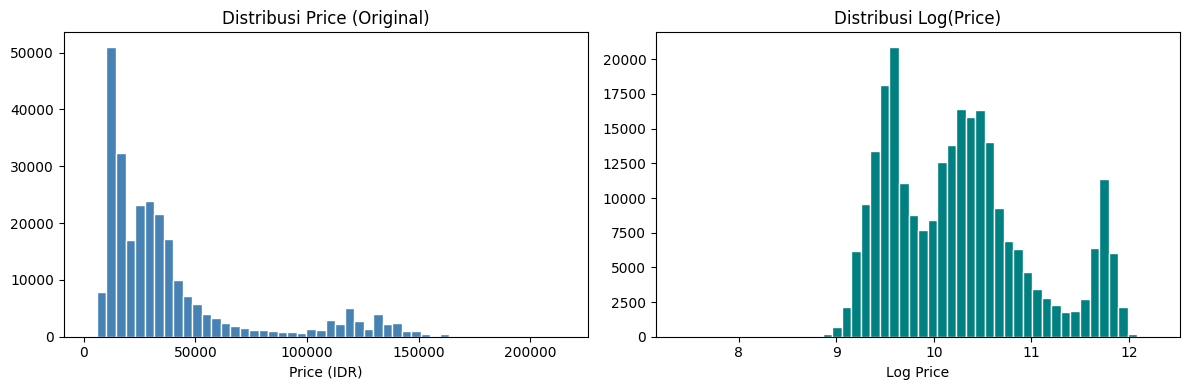

In [ ]:
# 3. LOG TRANSFORMATION (opsional: untuk distribusi price yang skewed)
# ─────────────────────────────────────────────
# Dilakukan SEBELUM normalisasi pada salinan terpisah (untuk analisis)
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Price (Original)')
plt.xlabel('Price (IDR)')

plt.subplot(1, 2, 2)
plt.hist(df['log_price'], bins=50, color='teal', edgecolor='white')
plt.title('Distribusi Log(Price)')
plt.xlabel('Log Price')

plt.tight_layout()
plt.show()



=== Distribusi Label (Discretization) ===
label_harga
2    127378
0     71762
1     65423
Name: count, dtype: int64


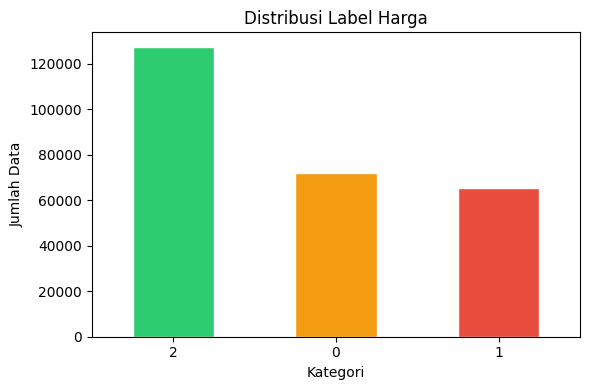

In [ ]:
# 4. DISCRETIZATION (sudah dilakukan saat labeling)
# Menampilkan distribusi label sebagai konfirmasi
# ─────────────────────────────────────────────
print("\n=== Distribusi Label (Discretization) ===")
print(df['label_harga'].value_counts())

label_counts = df['label_harga'].value_counts()
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
plt.title('Distribusi Label Harga')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# SIMPAN DATASET HASIL TRANSFORMASI
# ─────────────────────────────────────────────
df_encoded['label_harga'] = df['label_harga']  # tambahkan kembali label asli (string)

output_path = '/content/drive/MyDrive/dataset/dataset_transformed.csv'
df_encoded.to_csv(output_path, index=False)
print(f"\nDataset transformasi disimpan: {output_path}")
print(f"Total data: {len(df_encoded):,}")
print(df_encoded.head())


Dataset transformasi disimpan: /content/drive/MyDrive/dataset/dataset_transformed.csv
Total data: 264,563
   year  month  admin1  market  category  commodity     price  label_harga
0   0.0    0.0      14       0         0         15  0.020206            1
1   0.0    0.0      14       0         0         22  0.012643            1
2   0.0    0.0      14       0         1         26  0.035244            1
3   0.0    0.0      14       0         1          3  0.222780            0
4   0.0    0.0      14       0         1          7  0.086667            2
